# Project Description

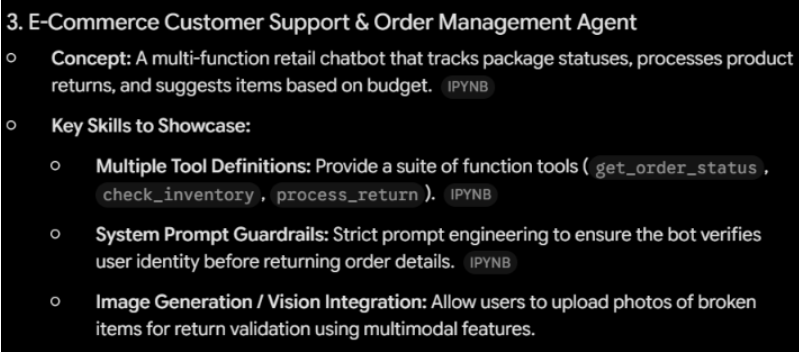

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

load_dotenv(override=True)

openai_api_key = os.getenv('API_KEY')
MODEL = "gpt-4.1-mini"
openai = OpenAI(api_key=openai_api_key)

# database Initialization
import sqlite3

def init_db(): #initialization of the database
    with sqlite3.connect("store.db") as conn:
        cursor = conn.cursor()
        
        # Customers Table
        cursor.execute('''CREATE TABLE IF NOT EXISTS customers (
            user_id TEXT PRIMARY KEY, pin TEXT, name TEXT
        )''')
        
        # Inventory Table
        cursor.execute('''CREATE TABLE IF NOT EXISTS inventory (
            item_id TEXT PRIMARY KEY, name TEXT, price REAL, stock INT
        )''')
        
        # Orders Table
        cursor.execute('''CREATE TABLE IF NOT EXISTS orders (
            order_id TEXT PRIMARY KEY, user_id TEXT, item_name TEXT, status TEXT, return_requested INT
        )''')
        
        # Seed Mock Data
        cursor.executemany('INSERT OR IGNORE INTO customers VALUES (?,?,?)', [
            ('USR101', '1234', 'Hasnain'),
            ('USR102', '5678', 'Ali')
        ])
        cursor.executemany('INSERT OR IGNORE INTO inventory VALUES (?,?,?,?)', [
            ('P001', 'Mechanical Keyboard', 85.00, 10),
            ('P002', 'Wireless Mouse', 30.00, 25),
            ('P003', 'Gaming Headset', 120.00, 5)
        ])
        cursor.executemany('INSERT OR IGNORE INTO orders VALUES (?,?,?,?,?)', [
            ('ORD991', 'USR101', 'Mechanical Keyboard', 'In Transit', 0),
            ('ORD992', 'USR101', 'Wireless Mouse', 'Delivered', 0)
        ])
        conn.commit()

init_db()



In [2]:
# Buidling the Backend Functions and Tool Schemas
import json

def verify_customer_identity(user_id,pin):
    with sqlite3.connect("store.db") as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT name from customers Where user_id=? AND pin=?",(user_id,str(pin)))
        res=cursor.fetchone()
        return f"SUCCES: Identity verified for {res[0]}" if res else "FAILED: Invalid User ID or PIN" 

def get_order_status(user_id, order_id):
    with sqlite3.connect("store.db") as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT item_name, status FROM orders WHERE order_id=? AND user_id=?", (order_id, user_id))
        res = cursor.fetchone()
        return f"Order {order_id} ({res[0]}): Status is '{res[1]}'" if res else "Order not found or unauthorized access."


def process_return(user_id, order_id, reason):
    conn = sqlite3.connect("store.db")
    cursor = conn.cursor()

    # 1. Fetch order details to verify ownership, item type, and status
    cursor.execute(
        "SELECT item_name, status FROM orders WHERE order_id = ? AND user_id = ?",
        (order_id, user_id)
    )
    row = cursor.fetchone()

    # 2. Check if order exists for this user
    if not row:
        conn.close()
        return f"Error: Order ID {order_id} not found for User {user_id}."

    item_name, status = row

    # 3. Check if order has been delivered
    if status != "Delivered":
        conn.close()
        return f"Error: Order {order_id} ({item_name}) cannot be returned because its current status is '{status}'."

    # 4. Process the return request
    cursor.execute(
        "UPDATE orders SET return_requested = 1 WHERE order_id = ? AND user_id = ?",
        (order_id, user_id)
    )
    conn.commit()
    conn.close()

    return f"Success: Return request for '{item_name}' (Order ID: {order_id}) has been successfully logged."

def check_inventory(max_price=None):
    with sqlite3.connect("store.db") as conn:
        cursor = conn.cursor()
        if max_price:
            cursor.execute("SELECT name, price FROM inventory WHERE price <= ? AND stock > 0", (max_price,))
        else:
            cursor.execute("SELECT name, price FROM inventory WHERE stock > 0")
        items = cursor.fetchall()
        return ", ".join([f"{name} (${price})" for name, price in items]) if items else "No matching items available."

# Define Tools Array
tools = [
    {
        "type": "function",
        "function": {
            "name": "verify_customer_identity",
            "description": "Verifies customer's credentials using User ID and 4-digit PIN.",
            "parameters": {
                "type": "object",
                "properties": {
                    "user_id": {"type": "string"},
                    "pin": {"type": "string"}
                },
                "required": ["user_id", "pin"],
                "additionalProperties": False
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_order_status",
            "description": "Fetch order status. ONLY run after identity verification succeeds.",
            "parameters": {
                "type": "object",
                "properties": {
                    "user_id": {"type": "string"},
                    "order_id": {"type": "string"}
                },
                "required": ["user_id", "order_id"],
                "additionalProperties": False
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "process_return",
            "description": "Logs a product return request.",
            "parameters": {
                "type": "object",
                "properties": {
                    "user_id": {"type": "string"},
                    "order_id": {"type": "string"},
                    "reason": {"type": "string"}
                },
                "required": ["user_id", "order_id", "reason"],
                "additionalProperties": False
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "check_inventory",
            "description": "Search in-stock products matching customer budget.",
            "parameters": {
                "type": "object",
                "properties": {
                    "max_price": {"type": "number", "description": "Maximum budget limit"}
                },
                "required": [],
                "additionalProperties": False
            }
        }
    }
]

In [3]:
system_message = """
You are 'JAVED', an AI Customer Support Agent for JAVED Retails.
Rule 1: NEVER call `get_order_status` or `process_return` UNTIL you have successfully run `verify_customer_identity` with the user's ID and PIN.
Rule 2: If the user asks about an order without providing user_id and pin, courteously ask for them first.
Rule 3: Keep responses concise, professional, and friendly.
"""

In [4]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode('utf-8')

def inspect_damaged_item(image_path):
    base64_img = encode_image(image_path)
    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": "Inspect this image of a returned item. Is there visible physical damage or defect? Answer in 2 short sentences."},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}}
            ]
        }]
    )
    return response.choices[0].message.content

In [8]:


def handle_tool_calls(message):
    responses = []
    
    # Iterate through every tool call requested by the LLM
    for tool_call in message.tool_calls:
        function_name = tool_call.function.name
        # Parse JSON string arguments into a Python dictionary
        arguments = json.loads(tool_call.function.arguments)
        
        # 1. Handle Identity Verification
        if function_name == "verify_customer_identity":
            result = verify_customer_identity(
                user_id=arguments.get("user_id"),
                pin=arguments.get("pin")
            )
            
        # 2. Handle Order Status Check
        elif function_name == "get_order_status":
            result = get_order_status(
                user_id=arguments.get("user_id"),
                order_id=arguments.get("order_id")
            )
            
        # 3. Handle Process Return
        elif function_name == "process_return":
            # TODO: Call your process_return function using arguments
             result = process_return(
                user_id=arguments.get("user_id"),
                order_id=arguments.get("order_id"),
                reason=arguments.get("reason")
            )
            
        # 4. Handle Inventory Search
        elif function_name == "check_inventory":
            # TODO: Call your check_inventory function using arguments
            result = check_inventory(
                max_price = arguments.get("max_price")
            )
        
        # Format and append the tool result message
        responses.append({
            "role": "tool",
            "content": str(result),
            "tool_call_id": tool_call.id
        })
        
    return responses

In [9]:
import base64

def encode_image_to_base64(image_path):
    with open(image_path, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode('utf-8')

def chat(message, history):
    #  Convert Gradio's history format into standard OpenAI message dictionaries
    formatted_history = []
    for turn in history:
        formatted_history.append({"role": turn["role"], "content": turn["content"]})

    #Extract user text and image files from gradio input
    if isinstance(message,dict):#if message is dict type
        text_content = message.get("text","")
        files = message.get("files",[])
    else:
        text_content = message
        files = []

    # Build Current user message payload
    user_content=[]


    # Add text prompt if provided 
    if text_content:
        user_content.append({"type":"text","text":text_content})


    # Add Base64 encoded image if uploaded

    for file_path in files:
        base64_image = encode_image_to_base64(file_path)
        user_content.append({
            "type":"image_url",
            "image_url":{
                "url":f"data:image/jpeg;base64,{base64_image}"
            }
        })

    # Assemble full message history
    current_user_message = {"role":"user","content":user_content}
    messages = [{"role":"system","content":system_message}]+formatted_history+[current_user_message]


    
    # . Initial call to the LLM with tool schemas
    response = openai.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools
    )
    
    # 5. Tool execution loop 
    while response.choices[0].finish_reason == "tool_calls":
        assistant_message = response.choices[0].message
        tool_responses = handle_tool_calls(assistant_message)
        
        messages.append(assistant_message)
        messages.extend(tool_responses)
        
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=messages,
            tools=tools
        )

    return response.choices[0].message.content

In [11]:
import gradio as gr

# Build the Multimodal Interface
demo = gr.ChatInterface(
    fn=chat,
    multimodal=True,  # Enables file/image uploads in the UI
    textbox=gr.MultimodalTextbox(
        placeholder="Type a message or upload an image...",
        file_types=["image"]
    )
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "C:\Users\Dell\anaconda3\Lib\site-packages\gradio\queueing.py", line 882, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "C:\Users\Dell\anaconda3\Lib\site-packages\gradio\route_utils.py", line 410, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<12 lines>...
    )
    ^
  File "C:\Users\Dell\anaconda3\Lib\site-packages\gradio\blocks.py", line 2330, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<9 lines>...
    )
    ^
  File "C:\Users\Dell\anaconda3\Lib\site-packages\gradio\blocks.py", line 1688, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\Lib\site-packages\gradio\utils.py", line 1081, in async_wrapper
    respons